# Demo: Feedforward Neural Networks for Multi-Class Classification
This notebook uses the **Wine** dataset to show:
- multi-class classification with FFNN
- comparison with Logistic Regression, Random Forest, and SVM
- confusion matrix and class probabilities
- hyperparameter tuning for multi-class FFNN

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data = load_wine(as_frame=True)
X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Class names:", list(data.target_names))
X.head()

Dataset shape: (178, 13)
Class names: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

## Compare several classifiers

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
    "FFNN (baseline)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier( # Output layer with K=3 neurons, apply softmax with cross-entropy loss 
            hidden_layer_sizes=(40, 20),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=1200,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro")
    })

pd.DataFrame(rows).sort_values("Accuracy", ascending=False)

,Model,Accuracy,Macro F1
0,Logistic Regression,1.000000,1.000000
1,Random Forest,1.000000,1.000000
2,SVM (RBF),0.977778,0.976498
3,FFNN (baseline),0.488889,0.406692


In [5]:
ffnn = models["FFNN (baseline)"]
ffnn.fit(X_train, y_train)

y_pred = ffnn.predict(X_test)
y_prob = ffnn.predict_proba(X_test)

print("Predicted probabilities for first 5 test instances:")
print(np.round(y_prob[:5], 3))
print("\nEach row sums to:", np.round(y_prob[:5].sum(axis=1), 3))

Predicted probabilities for first 5 test instances:
[[0.542 0.095 0.364]
 [0.531 0.259 0.21 ]
 [0.553 0.051 0.396]
 [0.54  0.086 0.373]
 [0.402 0.237 0.361]]

Each row sums to: [1. 1. 1. 1. 1.]


              precision    recall  f1-score   support

     class_0       0.50      0.67      0.57        15
     class_1       0.00      0.00      0.00        18
     class_2       0.48      1.00      0.65        12

    accuracy                           0.49        45
   macro avg       0.33      0.56      0.41        45
weighted avg       0.29      0.49      0.36        45



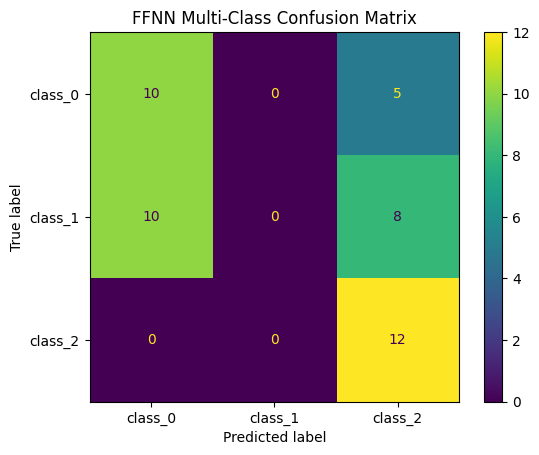

In [6]:
print(classification_report(y_test, y_pred, target_names=data.target_names))
ConfusionMatrixDisplay.from_estimator(ffnn, X_test, y_test, display_labels=data.target_names)
plt.title("FFNN Multi-Class Confusion Matrix")
plt.show()

## Hyperparameter tuning for FFNN

In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        solver="adam",
        activation="relu",
        max_iter=1500,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(20,), (40,), (50, 20), (60, 30)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.0005, 0.001, 0.005]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (40,), 'model__learning_rate_init': 0.005}
Best CV accuracy: 0.9322



Test accuracy: 0.8889
Test macro F1: 0.8958


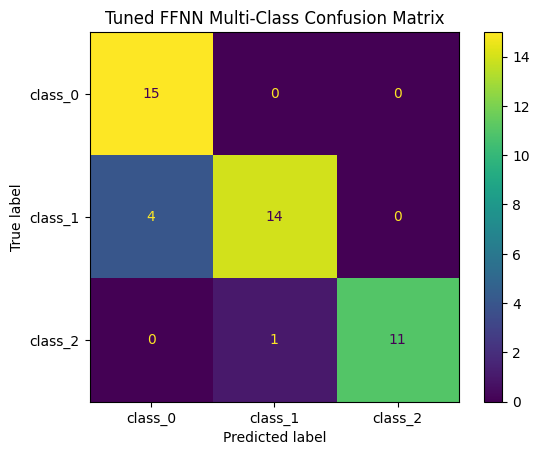

In [8]:
best_ffnn = grid.best_estimator_
y_pred_best = best_ffnn.predict(X_test)

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("Test macro F1:", round(f1_score(y_test, y_pred_best, average="macro"), 4))

ConfusionMatrixDisplay.from_estimator(best_ffnn, X_test, y_test, display_labels=data.target_names)
plt.title("Tuned FFNN Multi-Class Confusion Matrix")
plt.show()

#### How should one interpret the probability vector from `predict_proba`?